# 06 - Transfer Learning (MobileNetV2)

In [11]:
# ini yang pakai cpu
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## 1. Import dan Konfigurasi

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

NUM_THREADS = min(8, os.cpu_count() or 4)
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError as exc:
    print("Device TensorFlow sudah aktif, konfigurasi :", exc)

try:
    tf.config.threading.set_intra_op_parallelism_threads(NUM_THREADS)
    tf.config.threading.set_inter_op_parallelism_threads(NUM_THREADS)
except RuntimeError as exc:
    print("Threading TensorFlow sudah aktif, konfigurasi :", exc)

IMG_SIZE = (192, 192)
BATCH_SIZE = 10
SEED = 42

EPOCHS_HEAD = 10
DO_FINETUNE = True
EPOCHS_FINETUNE = 5
UNFREEZE_LAST_N = 10

LR_HEAD = 1e-3
LR_FINETUNE = 1e-5

keras.utils.set_random_seed(SEED)

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR / "data" / "split").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = Path("..").resolve()

DIR_ORIGINAL = PROJECT_ROOT / "data" / "split" # INI SALAH WKWKWKKW
DIR_MODELS = PROJECT_ROOT / "models"
DIR_METRICS = PROJECT_ROOT / "results" / "metrics"
DIR_FIGURES = PROJECT_ROOT / "results" / "figures"

for d in (DIR_MODELS, DIR_METRICS, DIR_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ["biological", "cardboard", "glass", "metal", "paper", "plastic"]
NUM_CLASSES = len(EXPECTED_CLASSES)

print("TensorFlow:", tf.__version__)
print("Physical GPU:", tf.config.list_physical_devices("GPU"))
print("Logical GPU :", tf.config.list_logical_devices("GPU"))
print("Device mode : CPU")
print("CPU threads :", NUM_THREADS)
print("Project root:", PROJECT_ROOT)
print("Dataset    :", DIR_ORIGINAL, "->", DIR_ORIGINAL.exists())
print("IMG_SIZE   :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)

TensorFlow: 2.21.0
Physical GPU: []
Logical GPU : []
Device mode : CPU
CPU threads : 8
Project root: C:\Users\User\Downloads\Waste Classification - PCD Project
Dataset    : C:\Users\User\Downloads\Waste Classification - PCD Project\data\split -> True
IMG_SIZE   : (192, 192)
BATCH_SIZE : 10


## 2. Helper Evaluasi

In [13]:
def compute_metrics(y_true, y_pred):
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "precision_macro": round(float(p_macro), 4),
        "recall_macro": round(float(r_macro), 4),
        "f1_macro": round(float(f_macro), 4),
    }


def plot_confusion(y_true, y_pred, class_names, title, file_name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Label Asli")
    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)
    return cm


def eval_on_test(model, ds_test):
    y_true, y_pred = [], []
    for xb, yb in ds_test:
        probs = model.predict(xb, verbose=0)
        pred = probs.argmax(axis=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())
    return np.array(y_true), np.array(y_pred)

## 3. Pipeline Data

In [14]:
def make_datasets(base_dir):
    def load(split, shuffle):
        return keras.utils.image_dataset_from_directory(
            base_dir / split,
            labels="inferred",
            label_mode="int",
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=SEED,
        )

    ds_train = load("train", True)
    ds_val = load("val", False)
    ds_test = load("test", False)

    class_names = ds_train.class_names
    assert class_names == EXPECTED_CLASSES, f"Urutan kelas tidak sesuai: {class_names}"

    options = tf.data.Options()
    options.threading.private_threadpool_size = NUM_THREADS
    options.threading.max_intra_op_parallelism = 1

    ds_train = ds_train.with_options(options).prefetch(1)
    ds_val = ds_val.with_options(options).prefetch(1)
    ds_test = ds_test.with_options(options).prefetch(1)
    return ds_train, ds_val, ds_test, class_names


ds_train, ds_val, ds_test, CLASS_NAMES = make_datasets(DIR_ORIGINAL)
print("Kelas:", CLASS_NAMES)

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.05, seed=SEED),
    ],
    name="data_augmentation",
)

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.
Kelas: ['biological', 'cardboard', 'glass', 'metal', 'paper', 'plastic']


## 4. Model Transfer Learning

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


def build_transfer_model():
    keras.utils.set_random_seed(SEED)
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,),
    )
    base.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_CPU")
    model.compile(
        optimizer=keras.optimizers.Adam(LR_HEAD),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model, base


model, base_model = build_transfer_model()
model.summary()

Model: "MobileNetV2_CPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Training

In [16]:
HEAD_PATH = DIR_MODELS / "mobilenetv2_head_best.keras"
FINETUNE_PATH = DIR_MODELS / "mobilenetv2_finetune_best.keras"
BEST_PATH = DIR_MODELS / "mobilenetv2_best.keras"


def make_callbacks(path_model, patience=3):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(path_model),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


def plot_history(histories, title, file_name):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in histories:
        acc.extend(hist.history["accuracy"])
        val_acc.extend(hist.history["val_accuracy"])
        loss.extend(hist.history["loss"])
        val_loss.extend(hist.history["val_loss"])

    epochs = range(1, len(acc) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(epochs, acc, label="train")
    ax[0].plot(epochs, val_acc, label="val")
    ax[0].set_title(f"{title} - Accuracy")
    ax[0].set_xlabel("epoch")
    ax[0].legend()

    ax[1].plot(epochs, loss, label="train")
    ax[1].plot(epochs, val_loss, label="val")
    ax[1].set_title(f"{title} - Loss")
    ax[1].set_xlabel("epoch")
    ax[1].legend()

    if len(histories) > 1:
        boundary = len(histories[0].history["accuracy"]) + 0.5
        for item in ax:
            item.axvline(boundary, color="gray", ls="--", alpha=0.7)

    plt.tight_layout()
    path = DIR_FIGURES / file_name
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Disimpan:", path)

Training head MobileNetV2 di CPU...
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 111s 190ms/step - accuracy: 0.7759 - loss: 0.6310 - val_accuracy: 0.8131 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 96s 177ms/step - accuracy: 0.8610 - loss: 0.3859 - val_accuracy: 0.8512 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 102s 189ms/step - accuracy: 0.8892 - loss: 0.3050 - val_accuracy: 0.8659 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 99s 183ms/step - accuracy: 0.9025 - loss: 0.2640 - val_accuracy: 0.8754 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 101s 188ms/step - accuracy: 0.9135 - loss: 0.2300 - val_accuracy: 0.8694 - val_loss: 0.3235 - learning_rate: 0.0010
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9172 - loss: 0.2247
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
540/540 ━━━━━━━━━━━━━━

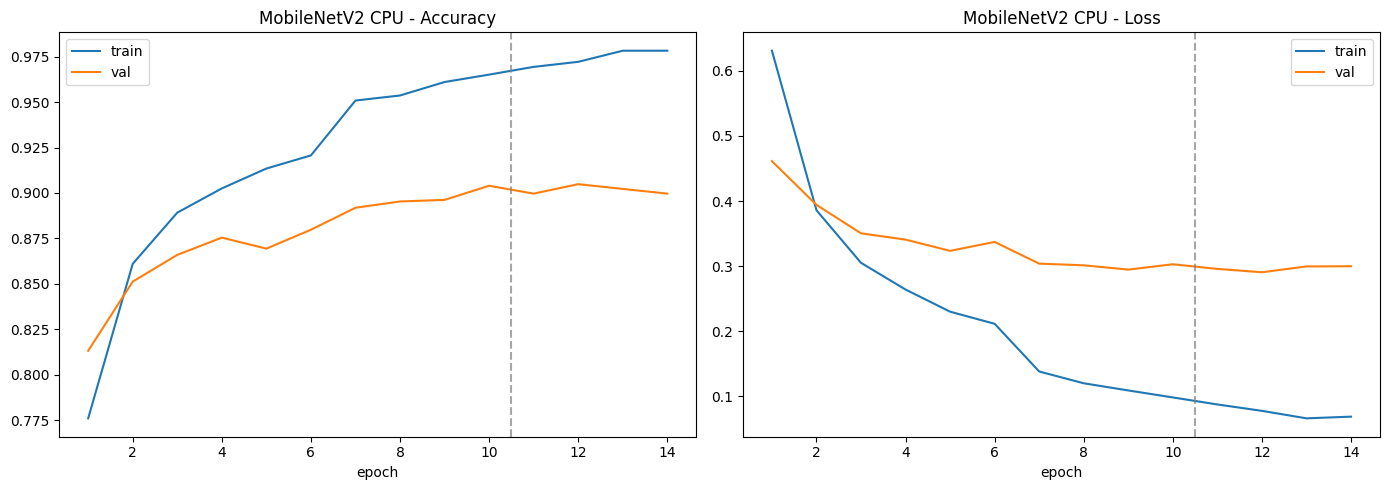

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\figures\training_history_mobilenetv2_cpu.png


In [17]:
rows = []
histories = []

print("Training head MobileNetV2 di CPU...")
history_head = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks(HEAD_PATH, patience=3),
    verbose=1,
)
histories.append(history_head)

model_head = keras.models.load_model(HEAD_PATH) if HEAD_PATH.exists() else model
y_head, pred_head = eval_on_test(model_head, ds_test)
m_head = compute_metrics(y_head, pred_head)
m_head.update({"model": "MobileNetV2_CPU", "scenario": "original", "phase": "head"})
rows.append(m_head)
print("Test head:", {k: m_head[k] for k in ("accuracy", "f1_macro")})

if DO_FINETUNE and EPOCHS_FINETUNE > 0:
    print(f"Fine-tuning ringan {UNFREEZE_LAST_N} layer akhir di CPU...")
    model = keras.models.load_model(HEAD_PATH) if HEAD_PATH.exists() else model
    base = next(layer for layer in model.layers if layer.name.startswith("mobilenetv2"))
    base.trainable = True
    for layer in base.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(LR_FINETUNE),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    history_ft = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS_FINETUNE,
        callbacks=make_callbacks(FINETUNE_PATH, patience=2),
        verbose=1,
    )
    histories.append(history_ft)

    model_ft = keras.models.load_model(FINETUNE_PATH) if FINETUNE_PATH.exists() else model
    y_ft, pred_ft = eval_on_test(model_ft, ds_test)
    m_ft = compute_metrics(y_ft, pred_ft)
    m_ft.update({"model": "MobileNetV2_CPU", "scenario": "original", "phase": "finetune"})
    rows.append(m_ft)
    print("Test finetune:", {k: m_ft[k] for k in ("accuracy", "f1_macro")})

plot_history(histories, "MobileNetV2 CPU", "training_history_mobilenetv2_cpu.png")

## 6. Evaluasi dan Simpan Hasil

In [18]:
df_tl = pd.DataFrame(rows)
df_tl = df_tl[[
    "model",
    "scenario",
    "phase",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
]]

metrics_path = DIR_METRICS / "transfer_learning_metrics.csv"
df_tl.to_csv(metrics_path, index=False)
print("Metrics disimpan:", metrics_path)
display(df_tl)

best_row = df_tl.loc[df_tl["f1_macro"].idxmax()]
selected_path = FINETUNE_PATH if best_row["phase"] == "finetune" and FINETUNE_PATH.exists() else HEAD_PATH
best_model = keras.models.load_model(selected_path)
best_model.save(BEST_PATH)
print("Model terbaik disimpan:", BEST_PATH)
print("Phase terbaik:", best_row["phase"])

y_true, y_pred = eval_on_test(best_model, ds_test)
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True,
)
df_report = pd.DataFrame(report).transpose()
report_path = DIR_METRICS / "classification_report_mobilenetv2.csv"
df_report.to_csv(report_path)
print("Classification report disimpan:", report_path)
display(df_report.round(3))

Metrics disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\metrics\transfer_learning_metrics.csv


,model,scenario,phase,accuracy,precision_macro,recall_macro,f1_macro
0,MobileNetV2_CPU,original,head,0.8885,0.8973,0.8988,0.8965
1,MobileNetV2_CPU,original,finetune,0.8989,0.9041,0.9061,0.9044


Model terbaik disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\models\mobilenetv2_best.keras
Phase terbaik: finetune
Classification report disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\metrics\classification_report_mobilenetv2.csv


,precision,recall,f1-score,support
biological,0.962,0.971,0.967,105.000
cardboard,0.953,0.868,0.909,212.000
glass,0.920,0.877,0.898,261.000
metal,0.868,0.899,0.883,139.000
paper,0.864,0.925,0.894,200.000
plastic,0.857,0.896,0.876,240.000
accuracy,0.899,0.899,0.899,0.899
macro avg,0.904,0.906,0.904,1157.000
weighted avg,0.901,0.899,0.899,1157.000


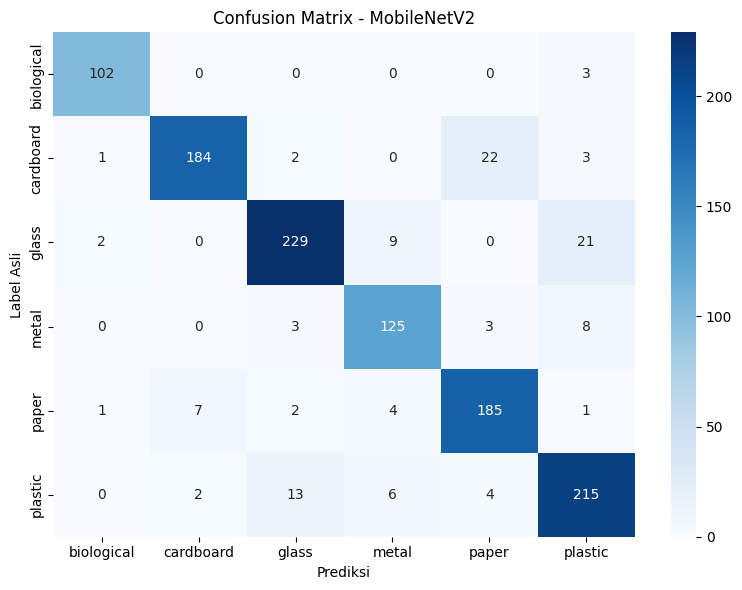

Disimpan: C:\Users\User\Downloads\Waste Classification - PCD Project\results\figures\confusion_matrix_mobilenetv2_cpu.png


In [21]:
cm = plot_confusion(
    y_true,
    y_pred,
    CLASS_NAMES,
    "Confusion Matrix - MobileNetV2",
    "confusion_matrix_mobilenetv2_cpu.png",
)

## 7. Ringkasan

In [20]:
BASELINE_RESULTS_PATH = PROJECT_ROOT / "results" / "cnn" / "model_comparison_original_vs_grabcut.csv"
df_baseline = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_row = df_baseline.loc[
    (df_baseline["model_name"] == "cnn_original_baseline")
    & (df_baseline["dataset"] == "original")
]

if baseline_row.empty:
    raise ValueError("Baseline CNN original tidak ditemukan di CSV hasil notebook 05")

BASELINE_F1_ORI = float(baseline_row.iloc[0]["f1_macro"])

best_row = df_tl.loc[df_tl["f1_macro"].idxmax()]
delta = best_row["f1_macro"] - BASELINE_F1_ORI

print("RINGKASAN TRANSFER LEARNING CPU")
print(f"Model terbaik : {best_row['model']} ({best_row['phase']})")
print(f"Accuracy      : {best_row['accuracy']:.4f}")
print(f"F1-macro      : {best_row['f1_macro']:.4f}")
print(f"Baseline F1   : {BASELINE_F1_ORI:.4f}")
print(f"Selisih       : {delta:+.4f}")



RINGKASAN TRANSFER LEARNING CPU
Model terbaik : MobileNetV2_CPU (finetune)
Accuracy      : 0.8989
F1-macro      : 0.9044
Baseline F1   : 0.5709
Selisih       : +0.3335
